To get the data required to perform analysis on online offline comparison for quality and type.

Strategy:
copy chirp mb fields with rois experiments into data_dj_format.

Create closed loop version of files in exp dir with cond1 being 666 or cl or whatever

### setup

In [36]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
from omegaconf import DictConfig, OmegaConf
import hydra
from hydra.utils import instantiate
from hydra.core.config_store import ConfigStore
from hydra import compose, initialize
from IPython.display import display
import sys
import os
from pathlib import Path


### SET THIS PATH FROM THE CURRENT WORKING DIRECTORY TO THE REPO DIRECTORY
relative_repo_path = "GitRepos/simulation_closed_loop"

In [5]:



# Add the parent directory to the path so we can import modules properly
cwd = Path.cwd()
full_repo_path = os.path.join(cwd, relative_repo_path)

if not os.path.exists(full_repo_path):
    raise ValueError(f"The specified relative path to the repo does not exist: {full_repo_path}\
                     Check workding dir and relative repo dir path variable.")

print(f"Working directoty: {cwd}")
print(f"Full repo path: {full_repo_path}")

# append repo path 
sys.path.append(full_repo_path)



# Initialize Hydra with the relative path to the config directory
config_path = os.path.join(relative_repo_path,"model_in_the_loop/config")
print(f"Config path relative to cwd: {config_path}")
if not os.path.exists(os.path.join(cwd,config_path)):
    raise ValueError(f"The specified config path does not exist: {os.path.join(cwd,config_path)}\
                     Check workding dir and config dir path variable.")

# Initialize Hydra
with initialize(version_base="1.3", config_path=config_path):
    # Compose the configuration
    cfg = compose(config_name="config")

# Print the config to verify it loaded correctly
print("Configuration loaded successfully:")



Working directoty: /gpfs01/euler/User/ssuhai
Full repo path: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop
Config path relative to cwd: GitRepos/simulation_closed_loop/model_in_the_loop/config
Configuration loaded successfully:


In [41]:
from model_in_the_loop.core import (DJTableHolder,Preprocessor,QualityAndTypeWrapper,STAWrapper,RandomSeedMEIWrapper,
                                                     )

from model_in_the_loop.utils.plotting import show_all_rois_plot
from model_in_the_loop.utils.file_management import copy_rec_files,create_directory_structure

from model_in_the_loop.utils.transform_to_avi_stimulus import create_single_mei_avis_and_metadata
from model_in_the_loop.utils.simple_logging import log

In [42]:
# set path to where I have data in datajoint format
cfg.DJ.userinfo.data_dir = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/data/online_quality_and_celltype/data_dj_format"
print(cfg.DJ.userinfo.data_dir)

/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/data/online_quality_and_celltype/data_dj_format


In [43]:
# create preprocessor
os.environ["DJ_SUPPORT_FILEPATH_MANAGEMENT"] = "TRUE"

dj_table_holder = DJTableHolder(
                username=cfg.DJ.username, # type: ignore
                
                #paths
                home_directory=cfg.paths.home_directory, # type: ignore
                repo_directory=cfg.paths.repo_directory, # type: ignore
                dj_config_directory= cfg.paths.dj_config_directory, # type: ignore
                rgc_output_directory= cfg.paths.rgc_output_directory, # type: ignore


                userinfo= cfg.DJ.userinfo, # type: ignore

                table_parameters=cfg.DJ.table_parameters, # type: ignore

                # from overall configs
                debug=cfg.debug, # type: ignore
                plot_results=cfg.plot_results, # type: ignore
                )



In [44]:
# # # Load config and tables
dj_table_holder.setup()

schema_name: ageuler_ssuhai_closed_loop


[2025-09-12 10:03:51,633][WARNING]: MySQL server has gone away. Reconnecting to the server.


Done reconnecting. Skipping adding new entries from config.


/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/model_in_the_loop/core/dj_wrappers/base.py:288: UserWarning: 
Some DJ tables (like UserInfo) are not empty, skipping adding new entries from config.
Make sure this is wanted. Call clear_tables(`all`) if you want different data in there
  warnings.warn("\nSome DJ tables (like UserInfo) are not empty, skipping adding new entries from config.\nMake sure this is wanted. Call clear_tables(`all`) if you want different data in there")


In [15]:
#dj_table_holder.clear_tables("all")
#dj_table_holder.setup()

schema_name: ageuler_ssuhai_closed_loop


/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/stimulus.py:195: UserWarning: Stimulus offset not set. Assuming 0 offset. This is incorrect for the standard dense noise stimulus.
  warnings.warn(
/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/stimulus.py:203: UserWarning: Stimulus offset not set. Assuming 0 offset. This is incorrect for the standard dense noise stimulus.
  warnings.warn(
/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/stimulus.py:112: UserWarning: Values for ['bardx', 'bardy', 'velumsec', 'tmovedurs'] in `stim_dict` for stimulus `movingbar` are None. This may cause problems downstream.
  warnings.warn(f'Values for {missing_info} in `stim_dict` for stimulus `{stim_name}` are None. '
/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/stimulus.py:39: UserWarning: Number of triggers in trial_info=8 must match ntrigger_rep=1.
  warnings.warn(msg)


preprocessing params:
 [{'preprocess_id': 1, 'fs_resample': 60, 'stim_names': ['gChirp', 'lChirp', 'movingbar', 'densenoise']}, {'preprocess_id': 2, 'window_length': 60, 'poly_order': 3, 'non_negative': 1, 'subtract_baseline': 0, 'standardize': 1, 'stim_names': ['mouse_cam']}]
Saving classifier to /gpfs01/euler/User/ssuhai/datajoint/rgc_classifier/rgc_classifier.pkl
Done setting up!


In [45]:
preprocessor = Preprocessor(dj_table_holder=dj_table_holder)


quality_type_analysis_wrapper = QualityAndTypeWrapper(
    dj_table_holder=dj_table_holder,)


In [46]:
preprocessor.upload_iteration_metadata()

Scanning for experimenter: closedlooptest
	header_path: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/data/online_quality_and_celltype/data_dj_format/20250813/2
		header_name: 20250813_1#20143_right.ini
		Already present: {'experimenter': 'closedlooptest', 'date': datetime.datetime(2025, 8, 13, 0, 0), 'exp_num': 2}
	header_path: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/data/online_quality_and_celltype/data_dj_format/20250324/1
		header_name: 20250324_1#20112_left.ini
		Adding: {'experimenter': 'closedlooptest', 'date': datetime.datetime(2025, 3, 24, 0, 0), 'exp_num': 1}
	header_path: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/data/online_quality_and_celltype/data_dj_format/20250820/1
		header_name: 20250820_1#20147_left.ini
		Already present: {'experimenter': 'closedlooptest', 'date': datetime.datetime(2025, 8, 20, 0, 0), 'exp_num': 1}


/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/experiment.py:135: UserWarning: Folder `Pre` not found in /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/data/online_quality_and_celltype/data_dj_format/20250324/1
  warnings.warn(f"Folder `{pre_data_dir}` not found in {header_path}")
Processes:   0%|          | 0/3 [00:00<?, ?it/s]/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/location/optic_disk.py:88: UserWarning: No optic disk information found for {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 8, 13), 'exp_num': 2, 'raw_id': 1}
  warnings.warn(f'No optic disk information found for {key}')
/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/location/optic_disk.py:88: UserWarning: No optic disk information found for {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1}
  warnings.warn(f'No optic disk information found for {key}')
/gpfs01/euler/User/ssuhai/GitRepos/d

Found 20 files in 10 fields for key={'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1}
	Adding field: `{'field': 'GCL1', 'region': 'LR', 'cond1': 'cl', 'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1}`
	Adding field: `{'field': 'GCL1', 'region': 'LR', 'cond1': 'n1', 'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1}`
	Adding field: `{'field': 'GCL2', 'region': 'LR', 'cond1': 'cl', 'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1}`
	Adding field: `{'field': 'GCL2', 'region': 'LR', 'cond1': 'n1', 'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1}`
	Adding field: `{'field': 'GCL3', 'region': 'LR', 'cond1': 'cl', 'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1}`
	Adding field: `{'field': 'GCL3', 'region': 'LR', '

Processes: 100%|██████████| 100/100 [00:03<00:00, 29.70it/s]


In [51]:
# load the existing ones
dj_table_holder("RoiMask")().rescan_filesystem(verboselvl=666)


field_key: {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL1', 'region': 'LR', 'cond1': 'cl'} 
pres_keys: [{'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL1', 'region': 'LR', 'cond1': 'cl', 'stim_name': 'gChirp', 'cond2': 'control'}, {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL1', 'region': 'LR', 'cond1': 'cl', 'stim_name': 'movingbar', 'cond2': 'control'}]
No ROI masks found for field: {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL1', 'region': 'LR', 'cond1': 'cl'}
pres_keys: [{'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL1', 'region': 'LR', 'cond1': 'cl', 'stim_name': 'gChirp', 'cond2': 'control'}, {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24

[]

In [52]:
dj_table_holder("RoiMask")()

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_mask ROI mask for recording field
closedlooptest,2025-03-24,1,1,GCL1,LR,n1,gChirp,control,=BLOB=
closedlooptest,2025-03-24,1,1,GCL2,LR,n1,gChirp,control,=BLOB=
closedlooptest,2025-03-24,1,1,GCL3,LR,n1,gChirp,control,=BLOB=
closedlooptest,2025-03-24,1,1,GCL4,LR,n1,gChirp,control,=BLOB=
closedlooptest,2025-03-24,1,1,GCL5,LR,n1,gChirp,control,=BLOB=
closedlooptest,2025-08-13,2,1,GCL2,RR,n1,gChirp,control,=BLOB=
closedlooptest,2025-08-13,2,1,GCL3,RR,n1,gChirp,control,=BLOB=
closedlooptest,2025-08-20,1,1,GCL1,LR,n1,gChirp,control,=BLOB=
closedlooptest,2025-08-20,1,1,GCL2,LR,n1,gChirp,control,=BLOB=
closedlooptest,2025-08-20,1,1,GCL3,LR,n1,gChirp,control,=BLOB=


In [53]:
missing_keys = dj_table_holder("RoiMask")().list_missing_field()
print("Missing keys in RoiMask table:", missing_keys)
print(len(missing_keys))

Missing keys in RoiMask table: [{'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL1', 'region': 'LR', 'cond1': 'cl'}, {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL2', 'region': 'LR', 'cond1': 'cl'}, {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL3', 'region': 'LR', 'cond1': 'cl'}, {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL4', 'region': 'LR', 'cond1': 'cl'}, {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL5', 'region': 'LR', 'cond1': 'cl'}, {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 8, 13), 'exp_num': 2, 'raw_id': 1, 'field': 'GCL2', 'region': 'RR', 'cond1': 'cl'}, {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 8, 13), 'exp_num': 2, '

In [54]:
for key in missing_keys:
    preprocessor.add_iteration_roi_mask(field_key=key)


field_key: {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL1', 'region': 'LR', 'cond1': 'cl'} 
pres_keys: [{'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL1', 'region': 'LR', 'cond1': 'cl', 'stim_name': 'gChirp', 'cond2': 'control'}, {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL1', 'region': 'LR', 'cond1': 'cl', 'stim_name': 'movingbar', 'cond2': 'control'}]
No ROI masks found for field: {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL1', 'region': 'LR', 'cond1': 'cl'}
pres_keys: [{'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL1', 'region': 'LR', 'cond1': 'cl', 'stim_name': 'gChirp', 'cond2': 'control'}, {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24

Returned InteractiveRoiCanvas object. To start GUI, call <enter_object_name>.start_gui().



field_key: {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL2', 'region': 'LR', 'cond1': 'cl'} 
pres_keys: [{'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL2', 'region': 'LR', 'cond1': 'cl', 'stim_name': 'gChirp', 'cond2': 'control'}, {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL2', 'region': 'LR', 'cond1': 'cl', 'stim_name': 'movingbar', 'cond2': 'control'}]
No ROI masks found for field: {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL2', 'region': 'LR', 'cond1': 'cl'}
pres_keys: [{'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL2', 'region': 'LR', 'cond1': 'cl', 'stim_name': 'gChirp', 'cond2': 'control'}, {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24

Returned InteractiveRoiCanvas object. To start GUI, call <enter_object_name>.start_gui().



field_key: {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL3', 'region': 'LR', 'cond1': 'cl'} 
pres_keys: [{'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL3', 'region': 'LR', 'cond1': 'cl', 'stim_name': 'gChirp', 'cond2': 'control'}, {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL3', 'region': 'LR', 'cond1': 'cl', 'stim_name': 'movingbar', 'cond2': 'control'}]
No ROI masks found for field: {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL3', 'region': 'LR', 'cond1': 'cl'}
pres_keys: [{'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL3', 'region': 'LR', 'cond1': 'cl', 'stim_name': 'gChirp', 'cond2': 'control'}, {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24

...

Returned InteractiveRoiCanvas object. To start GUI, call <enter_object_name>.start_gui().



field_key: {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 8, 20), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL2', 'region': 'LR', 'cond1': 'cl'} 
pres_keys: [{'experimenter': 'closedlooptest', 'date': datetime.date(2025, 8, 20), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL2', 'region': 'LR', 'cond1': 'cl', 'stim_name': 'gChirp', 'cond2': 'control'}, {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 8, 20), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL2', 'region': 'LR', 'cond1': 'cl', 'stim_name': 'movingbar', 'cond2': 'control'}]
No ROI masks found for field: {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 8, 20), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL2', 'region': 'LR', 'cond1': 'cl'}
pres_keys: [{'experimenter': 'closedlooptest', 'date': datetime.date(2025, 8, 20), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL2', 'region': 'LR', 'cond1': 'cl', 'stim_name': 'gChirp', 'cond2': 'control'}, {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 8, 20

Returned InteractiveRoiCanvas object. To start GUI, call <enter_object_name>.start_gui().



field_key: {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 8, 20), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL3', 'region': 'LR', 'cond1': 'cl'} 
pres_keys: [{'experimenter': 'closedlooptest', 'date': datetime.date(2025, 8, 20), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL3', 'region': 'LR', 'cond1': 'cl', 'stim_name': 'gChirp', 'cond2': 'control'}, {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 8, 20), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL3', 'region': 'LR', 'cond1': 'cl', 'stim_name': 'movingbar', 'cond2': 'control'}]
No ROI masks found for field: {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 8, 20), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL3', 'region': 'LR', 'cond1': 'cl'}
pres_keys: [{'experimenter': 'closedlooptest', 'date': datetime.date(2025, 8, 20), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL3', 'region': 'LR', 'cond1': 'cl', 'stim_name': 'gChirp', 'cond2': 'control'}, {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 8, 20

Returned InteractiveRoiCanvas object. To start GUI, call <enter_object_name>.start_gui().


In [57]:
dj_table_holder("RoiMask")().RoiMaskPresentation()

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_mask ROI mask for presentation field,as_field_mask relationship to field mask,shift_dx Shift in x,shift_dy Shift in y
closedlooptest,2025-03-24,1,1,GCL1,LR,cl,gChirp,control,=BLOB=,same,0,0
closedlooptest,2025-03-24,1,1,GCL1,LR,cl,movingbar,control,=BLOB=,shifted,0,1
closedlooptest,2025-03-24,1,1,GCL1,LR,n1,gChirp,control,=BLOB=,same,0,0
closedlooptest,2025-03-24,1,1,GCL1,LR,n1,movingbar,control,=BLOB=,same,0,0
closedlooptest,2025-03-24,1,1,GCL2,LR,cl,gChirp,control,=BLOB=,same,0,0
closedlooptest,2025-03-24,1,1,GCL2,LR,cl,movingbar,control,=BLOB=,shifted,0,-1
closedlooptest,2025-03-24,1,1,GCL2,LR,n1,gChirp,control,=BLOB=,same,0,0
closedlooptest,2025-03-24,1,1,GCL2,LR,n1,movingbar,control,=BLOB=,same,0,0
closedlooptest,2025-03-24,1,1,GCL3,LR,cl,gChirp,control,=BLOB=,same,0,0
closedlooptest,2025-03-24,1,1,GCL3,LR,cl,movingbar,control,=BLOB=,same,0,0


In [ ]:
dj_table_holder("Cellty")()

KeyError: 'Table Celltypeassigment not found in loaded tables'

In [58]:
preprocessor.add_iteration_rois()
preprocessor.add_iteration_traces()

[2025-09-12 10:48:11,156][WARNING]: MySQL server has gone away. Reconnecting to the server.


Processes: 100%|██████████| 3856/3856 [00:07<00:00, 516.43it/s]


In [59]:
quality_type_analysis_wrapper.compute_analysis()

Processes: 100%|██████████| 1927/1927 [00:04<00:00, 437.87it/s]
/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/classifier/rgc_classifier.py:402: UserWarning: Parallel processing not implemented!
  warnings.warn('Parallel processing not implemented!')
CelltypeAssignment: 100%|██████████| 20/20 [00:26<00:00,  1.30s/it]


In [61]:
quality_querey = dj_table_holder("OsDsIndexes")().proj(**{"stim_name_mb":"stim_name","mb_qidx":"d_qi"}) * dj_table_holder("ChirpQI")().proj(**{"stim_name_chirp":"stim_name","chirp_qidx":"qidx"})
quality_df = pd.DataFrame(quality_querey.fetch(as_dict=True))
display(quality_df.head())

,experimenter,date,exp_num,raw_id,field,region,cond1,stim_name_mb,cond2,roi_id,preprocess_id,stim_name_chirp,mb_qidx,chirp_qidx
0,closedlooptest,2025-03-24,1,1,GCL1,LR,cl,movingbar,control,1,1,gChirp,0.902922,0.394344
1,closedlooptest,2025-03-24,1,1,GCL1,LR,cl,movingbar,control,2,1,gChirp,0.888359,0.214798
2,closedlooptest,2025-03-24,1,1,GCL1,LR,cl,movingbar,control,3,1,gChirp,0.491751,0.234514
3,closedlooptest,2025-03-24,1,1,GCL1,LR,cl,movingbar,control,4,1,gChirp,0.880431,0.375522
4,closedlooptest,2025-03-24,1,1,GCL1,LR,cl,movingbar,control,5,1,gChirp,0.679782,0.252574


In [62]:
# add a field_nr column
all_field_keys = dj_table_holder("Field")().proj().fetch(as_dict=True)
print(len(all_field_keys), all_field_keys[0])

20 {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 3, 24), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL1', 'region': 'LR', 'cond1': 'cl'}


In [83]:

def add_field_id_col(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds inplace a field_id column to the dataframe that uniquely identifies a field (WITHOUT COND1)
    """

    # List the columns that uniquely define a field EXCLUDING COND1
    field_id_cols = ['experimenter', 'date', 'exp_num', 'raw_id', 'field', 'region']

    assert all(col in df.columns for col in field_id_cols), "One or more required columns are missing in the DataFrame"

    # Convert date to string if needed
    df['date'] = df['date'].astype(str)

    # Create the field_id column
    df['field_id'] = df[field_id_cols].astype(str).agg('_'.join, axis=1)

    # Display the result
    display(df.head())
    print(len(df['field_id'].unique()))



In [76]:
# define some functions to call 
def mean_mb_qidx(group):
    return group['mb_qidx'].mean()

def mean_chrip_qidx(group):
    return group['chirp_qidx'].mean()



def nr_passing_or(group,mb_thresh = 0.6,chirp_thresh= 0.35):
    return ((group['mb_qidx'] >= mb_thresh) | (group['chirp_qidx'] >= chirp_thresh)).sum()


def frac_passing_or(group,mb_thresh = 0.6,chirp_thresh = 0.35):
    return ((group['mb_qidx'] >= mb_thresh) | (group['chirp_qidx'] >= chirp_thresh)).mean()

In [77]:
# plot actual
from functools import partial 

# quality_df.groupby(['field_id','cond1']).apply(mean_chrip_qidx)
# quality_df.groupby(['field_id','cond1']).apply(mean_mb_qidx)
# quality_df.groupby(['field_id','cond1']).apply(nr_passing_or)
quality_df.groupby(['field_id','cond1']).apply(frac_passing_or)

/tmp/ipykernel_614628/2147842778.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  quality_df.groupby(['field_id','cond1']).apply(frac_passing_or)


field_id                               cond1
closedlooptest_2025-03-24_1_1_GCL1_LR  cl       0.534653
                                       n1       0.483333
closedlooptest_2025-03-24_1_1_GCL2_LR  cl       0.821782
                                       n1       0.819820
closedlooptest_2025-03-24_1_1_GCL3_LR  cl       0.591398
                                       n1       0.585106
closedlooptest_2025-03-24_1_1_GCL4_LR  cl       0.797753
                                       n1       0.782609
closedlooptest_2025-03-24_1_1_GCL5_LR  cl       0.588889
                                       n1       0.504854
closedlooptest_2025-08-13_2_1_GCL2_RR  cl       0.755556
                                       n1       0.780220
closedlooptest_2025-08-13_2_1_GCL3_RR  cl       0.911111
                                       n1       0.887640
closedlooptest_2025-08-20_1_1_GCL1_LR  cl       0.663366
                                       n1       0.717172
closedlooptest_2025-08-20_1_1_GCL2_LR  cl  

In [84]:
traces_df = dj_table_holder("Traces")().fetch(as_dict=True)
traces_df = pd.DataFrame(traces_df)
display(traces_df.head())
add_field_id_col(traces_df)

,experimenter,date,exp_num,raw_id,field,region,cond1,stim_name,cond2,roi_id,trace,trace_t0,trace_dt,trace_valid,trigger_valid
0,closedlooptest,2025-03-24,1,1,GCL1,LR,cl,gChirp,control,1,"[10936.23076923077, 10966.538461538461, 10967....",0.002,0.128,1,1
1,closedlooptest,2025-03-24,1,1,GCL1,LR,cl,gChirp,control,2,"[10936.214285714286, 10978.142857142857, 10976...",0.002,0.128,1,1
2,closedlooptest,2025-03-24,1,1,GCL1,LR,cl,gChirp,control,3,"[10935.6, 10984.8, 10987.4, 10983.4, 10986.6, ...",0.000,0.128,1,1
3,closedlooptest,2025-03-24,1,1,GCL1,LR,cl,gChirp,control,4,"[10936.875, 11293.166666666666, 11293.79166666...",0.004,0.128,1,1
4,closedlooptest,2025-03-24,1,1,GCL1,LR,cl,gChirp,control,5,"[10980.619047619048, 11004.0, 11002.0476190476...",0.010,0.128,1,1


,experimenter,date,exp_num,raw_id,field,region,cond1,stim_name,cond2,roi_id,trace,trace_t0,trace_dt,trace_valid,trigger_valid,field_id
0,closedlooptest,2025-03-24,1,1,GCL1,LR,cl,gChirp,control,1,"[10936.23076923077, 10966.538461538461, 10967....",0.002,0.128,1,1,closedlooptest_2025-03-24_1_1_GCL1_LR
1,closedlooptest,2025-03-24,1,1,GCL1,LR,cl,gChirp,control,2,"[10936.214285714286, 10978.142857142857, 10976...",0.002,0.128,1,1,closedlooptest_2025-03-24_1_1_GCL1_LR
2,closedlooptest,2025-03-24,1,1,GCL1,LR,cl,gChirp,control,3,"[10935.6, 10984.8, 10987.4, 10983.4, 10986.6, ...",0.000,0.128,1,1,closedlooptest_2025-03-24_1_1_GCL1_LR
3,closedlooptest,2025-03-24,1,1,GCL1,LR,cl,gChirp,control,4,"[10936.875, 11293.166666666666, 11293.79166666...",0.004,0.128,1,1,closedlooptest_2025-03-24_1_1_GCL1_LR
4,closedlooptest,2025-03-24,1,1,GCL1,LR,cl,gChirp,control,5,"[10980.619047619048, 11004.0, 11002.0476190476...",0.010,0.128,1,1,closedlooptest_2025-03-24_1_1_GCL1_LR


10


In [85]:
celltypes_df = dj_table_holder("CelltypeAssignment")().fetch(as_dict=True)
celltypes_df = pd.DataFrame(celltypes_df)
display(celltypes_df.head())
add_field_id_col(celltypes_df)

,experimenter,date,exp_num,raw_id,field,region,cond1,avg_stim_name,cond2,roi_id,preprocess_id,os_ds_stim_name,training_data_hash,classifier_params_hash,celltype,max_confidence,confidence
0,closedlooptest,2025-03-24,1,1,GCL1,LR,cl,gChirp,control,1,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,33,0.284521,"[0.012845317441224169, 0.015321111423074452, 0..."
1,closedlooptest,2025-03-24,1,1,GCL1,LR,cl,gChirp,control,2,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,2,0.434690,"[0.028415981506272277, 0.43468964483071887, 0...."
2,closedlooptest,2025-03-24,1,1,GCL1,LR,cl,gChirp,control,3,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,17,0.230961,"[0.002105841622633011, 0.0020576724877037615, ..."
3,closedlooptest,2025-03-24,1,1,GCL1,LR,cl,gChirp,control,4,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,33,0.306937,"[0.0026672991161821964, 0.016455869301186775, ..."
4,closedlooptest,2025-03-24,1,1,GCL1,LR,cl,gChirp,control,5,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,4,0.371878,"[0.0032660243652177603, 0.11242400521111869, 0..."


,experimenter,date,exp_num,raw_id,field,region,cond1,avg_stim_name,cond2,roi_id,preprocess_id,os_ds_stim_name,training_data_hash,classifier_params_hash,celltype,max_confidence,confidence,field_id
0,closedlooptest,2025-03-24,1,1,GCL1,LR,cl,gChirp,control,1,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,33,0.284521,"[0.012845317441224169, 0.015321111423074452, 0...",closedlooptest_2025-03-24_1_1_GCL1_LR
1,closedlooptest,2025-03-24,1,1,GCL1,LR,cl,gChirp,control,2,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,2,0.434690,"[0.028415981506272277, 0.43468964483071887, 0....",closedlooptest_2025-03-24_1_1_GCL1_LR
2,closedlooptest,2025-03-24,1,1,GCL1,LR,cl,gChirp,control,3,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,17,0.230961,"[0.002105841622633011, 0.0020576724877037615, ...",closedlooptest_2025-03-24_1_1_GCL1_LR
3,closedlooptest,2025-03-24,1,1,GCL1,LR,cl,gChirp,control,4,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,33,0.306937,"[0.0026672991161821964, 0.016455869301186775, ...",closedlooptest_2025-03-24_1_1_GCL1_LR
4,closedlooptest,2025-03-24,1,1,GCL1,LR,cl,gChirp,control,5,1,movingbar,7c5bdca5b59dd970f8e1aebfe86323db,e705a7d0cb4119f76d9064a57a2b527f,4,0.371878,"[0.0032660243652177603, 0.11242400521111869, 0...",closedlooptest_2025-03-24_1_1_GCL1_LR


10


In [151]:
import numpy as np
def find_row_with_highest_correl(row: np.ndarray,arr:np.ndarray) -> tuple[int,float]:
    """
    returns the row in arr with the highest correlation to row
    """
    assert len(row.shape) == 1, "row must be 1D"
    assert len(arr.shape) == 2, "arr must be 2D"
    correlations = np.corrcoef(row, arr)[0, 1:]
    max_corr_index = np.argmax(correlations).astype(int)
    max_corr_value = correlations[max_corr_index].astype(float)
    return max_corr_index, max_corr_value


def find_offline_roi_id_partner(field_traces: pd.DataFrame,online_col_val = 'cl',offline_col_val = 'n1',field_id_col = 'field_id',cond1_col = 'cond1'):
    """
    Find the offline roi id that has the highest correlation with the online roi id
    """
    assert field_traces[field_id_col].unique().size == 1, "field_traces must contain only one field_id"
    online_field_traces = field_traces[field_traces[cond1_col] == online_col_val]
    offline_field_traces = field_traces[field_traces[cond1_col] == offline_col_val]

    online_offlie_mapping = {}
    online_offline_corrs = {}
    # find online field_id entoes
    offline_traces_array = np.stack(offline_field_traces['trace'].to_list(),axis = 0)
    assert offline_traces_array.shape[0] == len(offline_field_traces), f"Number of offline traces {offline_traces_array.shape[0]} does not match number of offline rois {len(offline_field_traces)}"

    print(offline_traces_array.shape)
    for i,df_row in online_field_traces.iterrows():
        online_roi_id = df_row['roi_id']
        online_trace = df_row['trace']
        offline_idx, corr = find_row_with_highest_correl(online_trace,offline_traces_array)
        offline_roi_id = offline_field_traces.iloc[offline_idx]['roi_id']
        online_offlie_mapping[online_roi_id] = offline_roi_id
        online_offline_corrs[online_roi_id] = corr
    return online_offlie_mapping, online_offline_corrs

def online2offline_celltype(field_celltypes_df, traces_df=traces_df, online_col_val = 'cl',offline_col_val = 'n1',field_id_col = 'field_id',cond1_col = 'cond1',stim_name = 'gChirp', quality_df = quality_df):
    """
    Given a dataframe with celltypes for online rois, find the corresponding offline roi celltypes
    """

    all_field_ids = field_celltypes_df[field_id_col].unique()
    assert len(all_field_ids) == 1, "field_celltypes_df must contain only one field_id"
    field_id = all_field_ids[0]

    stim_mask = traces_df['stim_name'] == stim_name
    field_traces = traces_df[(traces_df[field_id_col] == field_id) & stim_mask]
    
    online_offlie_mapping, online_offline_corrs = find_offline_roi_id_partner(field_traces,online_col_val,offline_col_val,field_id_col,cond1_col)
    
    # first get onlz online celltypes 
    online_celltypes = field_celltypes_df[field_celltypes_df['cond1'] == online_col_val][['roi_id','celltype','max_confidence']].rename(columns={'roi_id':'online_roi_id','celltype':'online_cell_type','max_confidence':'online_max_confidence'})
    offline_celltypes = field_celltypes_df[field_celltypes_df['cond1'] == offline_col_val][['roi_id','celltype']].rename(columns={'roi_id':'offline_roi_id','celltype':'offline_cell_type'})
    
    # reset indices
    online_celltypes = online_celltypes.reset_index(drop=True)
    offline_celltypes = offline_celltypes.reset_index(drop=True)


    # find quality indices for online rois
    field_quality_online = quality_df[(quality_df[field_id_col] == field_id) & (quality_df['cond1'] == online_col_val)]


    # then also offline
    out_df = online_celltypes.copy()

    out_df["offline_roi_id"] = out_df['online_roi_id'].map(online_offlie_mapping)
    out_df["correlation"] = out_df['online_roi_id'].map(online_offline_corrs)

    # add corresponing offline celltype and qidxs
    chirp_qidxs = []
    mb_qidxs = []
    corresponding_offline_celltypes = []
    for i,row in out_df.iterrows():
        offline_roi_id = row['offline_roi_id']
    
        offline_cell_type = offline_celltypes[offline_celltypes['offline_roi_id'] == offline_roi_id]['offline_cell_type']
        assert len(offline_cell_type) == 1
        corresponding_offline_celltypes.append(offline_cell_type.item())

        quality_row = field_quality_online[field_quality_online['roi_id'] == row['online_roi_id']]
        assert len(quality_row) == 1, f"Could not find quality row for online_roi_id {row['online_roi_id']}"
        chirp_qidxs.append(quality_row['chirp_qidx'].item())
        mb_qidxs.append(quality_row['mb_qidx'].item())

    out_df['offline_cell_type'] = corresponding_offline_celltypes
    out_df['chirp_qidx'] = chirp_qidxs
    out_df['mb_qidx'] = mb_qidxs

    out_df[field_id_col] = field_id
    return out_df

def get_all_online2offline_celltype(all_celltypes_df, traces_df=traces_df, online_col_val = 'cl',offline_col_val = 'n1',field_id_col = 'field_id',cond1_col = 'cond1'):
    """
    Loops over field_ids in the entire celltype df and then calls online2offline_celltype and concatenates the results to one df with some sanity checks at end.
    """
    out_dfs = []
    for i,field_id in enumerate(all_celltypes_df[field_id_col].unique()):
        field_celltypes_df = all_celltypes_df[all_celltypes_df[field_id_col] == field_id]
        field_out_df = online2offline_celltype(field_celltypes_df,traces_df,online_col_val,offline_col_val,field_id_col,cond1_col)
        out_dfs.append(field_out_df)
    out_df = pd.concat(out_dfs,ignore_index=True)
    # sanity checks
    assert sum(all_celltypes_df['cond1'] == online_col_val) == len(out_df)

    # same nr of rois as online for each field 
    assert all(out_df.groupby(field_id_col).size() == all_celltypes_df[all_celltypes_df['cond1'] == online_col_val].groupby(field_id_col).size())


    return out_df
    

    
   


In [152]:
online2offline_celltype_df = get_all_online2offline_celltype(all_celltypes_df=celltypes_df,traces_df=traces_df, online_col_val = 'cl',offline_col_val = 'n1',field_id_col = 'field_id',cond1_col = 'cond1')

(120, 1488)
(111, 1790)
(94, 1474)
(92, 1524)
(103, 1527)
(91, 1535)
(89, 1498)
(99, 1622)
(76, 1498)
(114, 1492)


In [153]:
online2offline_celltype_df.head()

,online_roi_id,online_cell_type,online_max_confidence,offline_roi_id,correlation,offline_cell_type,chirp_qidx,mb_qidx,field_id
0,1,33,0.284521,83,0.935912,33,0.394344,0.902922,closedlooptest_2025-03-24_1_1_GCL1_LR
1,2,2,0.434690,1,0.957596,2,0.214798,0.888359,closedlooptest_2025-03-24_1_1_GCL1_LR
2,3,17,0.230961,2,0.954992,17,0.234514,0.491751,closedlooptest_2025-03-24_1_1_GCL1_LR
3,4,33,0.306937,3,0.940017,4,0.375522,0.880431,closedlooptest_2025-03-24_1_1_GCL1_LR
4,5,4,0.371878,5,0.838498,33,0.252574,0.679782,closedlooptest_2025-03-24_1_1_GCL1_LR


## save the data

In [ ]:
data_dir = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/data/online_quality_and_celltype"

import pickle


In [ ]:
def prepare_celltype_data(df, offline_col='offline_cell_type', online_col='online_cell_type',
                          max_type=32, chirp_qidx_threshold=None, mb_qidx_threshold=None,
                          chirp_percentile=None, mb_percentile=None):
    """
    Prepare cell type data for confusion matrix analysis, with optional quality filtering.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing cell type and quality data
    offline_col : str
        Column name for offline cell types
    online_col : str
        Column name for online cell types
    max_type : int
        Maximum cell type to show individually (higher values grouped)
    chirp_qidx_threshold : float, optional
        Minimum chirp quality index threshold (cells below will be filtered out)
    mb_qidx_threshold : float, optional
        Minimum moving bar quality index threshold (cells below will be filtered out)
    chirp_percentile : float, optional
        Percentile for automatic chirp threshold selection (between 0 and 100)
    mb_percentile : float, optional
        Percentile for automatic moving bar threshold selection (between 0 and 100)
        
    Returns:
    --------
    df_prepared : pandas.DataFrame
        Filtered and prepared DataFrame with grouped cell types
    applied_thresholds : dict
        Dictionary with the applied threshold values
    """
    import pandas as pd
    import numpy as np
    
    # Assert that user doesn't specify both percentile and threshold for the same metric
    if chirp_percentile is not None and chirp_qidx_threshold is not None:
        raise ValueError("Cannot specify both chirp_percentile and chirp_qidx_threshold")
        
    if mb_percentile is not None and mb_qidx_threshold is not None:
        raise ValueError("Cannot specify both mb_percentile and mb_qidx_threshold")
    
    # Create a copy to avoid modifying the original DataFrame
    df_copy = df.copy()
    
    # Calculate and apply percentile-based thresholds if specified
    applied_thresholds = {}
    
    if chirp_percentile is not None:
        if 'chirp_qidx' not in df_copy.columns:
            raise ValueError("Column 'chirp_qidx' not found but chirp_percentile was specified")
        chirp_qidx_threshold = np.percentile(df_copy['chirp_qidx'], chirp_percentile)
        applied_thresholds['chirp_qidx'] = chirp_qidx_threshold
    
    if mb_percentile is not None:
        if 'mb_qidx' not in df_copy.columns:
            raise ValueError("Column 'mb_qidx' not found but mb_percentile was specified")
        mb_qidx_threshold = np.percentile(df_copy['mb_qidx'], mb_percentile)
        applied_thresholds['mb_qidx'] = mb_qidx_threshold
    
    # Apply quality thresholds if specified
    if chirp_qidx_threshold is not None:
        if 'chirp_qidx' not in df_copy.columns:
            raise ValueError("Column 'chirp_qidx' not found but chirp_qidx_threshold was specified")
        df_copy = df_copy[df_copy['chirp_qidx'] >= chirp_qidx_threshold]
        if 'chirp_qidx' not in applied_thresholds:
            applied_thresholds['chirp_qidx'] = chirp_qidx_threshold
    
    if mb_qidx_threshold is not None:
        if 'mb_qidx' not in df_copy.columns:
            raise ValueError("Column 'mb_qidx' not found but mb_qidx_threshold was specified")
        df_copy = df_copy[df_copy['mb_qidx'] >= mb_qidx_threshold]
        if 'mb_qidx' not in applied_thresholds:
            applied_thresholds['mb_qidx'] = mb_qidx_threshold
    
    # Group cell types > max_type into a single category
    df_copy[offline_col + '_grouped'] = df_copy[offline_col].apply(
        lambda x: x if x <= max_type else max_type + 1)
    df_copy[online_col + '_grouped'] = df_copy[online_col].apply(
        lambda x: x if x <= max_type else max_type + 1)
    
    return df_copy, applied_thresholds


def create_confusion_matrices(df, offline_col_grouped, online_col_grouped, max_type=32):
    """
    Create confusion matrices for cell type classification analysis.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Prepared DataFrame containing grouped cell type columns
    offline_col_grouped : str
        Column name for grouped offline cell types
    online_col_grouped : str
        Column name for grouped online cell types
    max_type : int
        Maximum cell type shown individually
        
    Returns:
    --------
    confusion_counts : pandas.DataFrame
        Matrix of raw counts
    confusion_probs : pandas.DataFrame
        Matrix of row-normalized probabilities
    """
    import pandas as pd
    
    # Create the contingency table
    confusion_counts = pd.crosstab(
        df[offline_col_grouped], 
        df[online_col_grouped],
        rownames=['Offline Type'], 
        colnames=['Online Type']
    )
    
    # Ensure all values from 1 to max_type+1 are present in both axes
    all_values = list(range(1, max_type + 2))
    for val in all_values:
        if val not in confusion_counts.index:
            confusion_counts.loc[val] = 0
        if val not in confusion_counts.columns:
            confusion_counts[val] = 0
    
    # Sort both axes
    confusion_counts = confusion_counts.sort_index().sort_index(axis=1)
    
    # Create row-normalized matrix (probabilities)
    confusion_probs = confusion_counts.div(confusion_counts.sum(axis=1), axis=0).fillna(0)
    
    return confusion_counts, confusion_probs


def plot_confusion_matrix(matrix, is_counts=True, max_type=32, figsize=(20, 16), 
                          cmap='Blues', annot_fmt='.2f', applied_thresholds=None):
    """
    Plot a single confusion matrix (either counts or probabilities).
    
    Parameters:
    -----------
    matrix : pandas.DataFrame
        Matrix to plot (either counts or probabilities)
    is_counts : bool
        Whether the matrix contains counts (True) or probabilities (False)
    max_type : int
        Maximum cell type shown individually
    figsize : tuple
        Figure size (width, height)
    cmap : str
        Colormap for the heatmaps
    annot_fmt : str
        Format string for annotations
    applied_thresholds : dict, optional
        Dictionary with applied quality thresholds to show in title
        
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The created figure
    ax : matplotlib.axes.Axes
        The axes object
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Create a figure
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Format depends on whether this is counts or probabilities
    fmt = 'd' if is_counts else annot_fmt
    label = 'Count' if is_counts else 'Probability'
    
    # Plot the matrix
    sns.heatmap(matrix, annot=True, fmt=fmt, cmap=cmap, 
                ax=ax, cbar_kws={'label': label})
    
    # Update labels
    ax.set_xlabel('Online Cell Type')
    ax.set_ylabel('Offline Cell Type')
    
    # Set title
    if is_counts:
        title = 'Cell Type Classification Confusion Matrix (Counts)'
        total_cells = matrix.sum().sum()
        title += f'\nTotal: {int(total_cells)} cells'
    else:
        title = 'Cell Type Classification Conditional Probability\n(P(online type | offline type))'
    
    if applied_thresholds:
        threshold_str = ', '.join([f"{k}: {v:.3f}" for k, v in applied_thresholds.items()])
        title += f'\nQuality thresholds: {threshold_str}'
    
    ax.set_title(title)
    
    # Rename the last tick label to ">32"
    xticks = list(range(1, max_type + 1)) + [f">{max_type}"]
    yticks = list(range(1, max_type + 1)) + [f">{max_type}"]
    ax.set_xticklabels(xticks)
    ax.set_yticklabels(yticks)
    
    plt.tight_layout()
    
    return fig, ax


def plot_celltype_confusion_matrix(df, offline_col='offline_cell_type', online_col='online_cell_type', 
                                  max_type=32, figsize=(20, 16), cmap='Blues', annot_fmt='.2f',
                                  plot_counts=True, save_path=None,
                                  chirp_qidx_threshold=None, mb_qidx_threshold=None,
                                  chirp_percentile=None, mb_percentile=None):
    """
    Plot a confusion matrix for cell type classifications with optional quality filtering.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing the classification data
    offline_col : str
        Column name for offline cell types (rows)
    online_col : str
        Column name for online cell types (columns)
    max_type : int
        Maximum cell type to show individually (higher values grouped)
    figsize : tuple
        Figure size (width, height)
    cmap : str
        Colormap for the heatmaps
    annot_fmt : str
        Format string for annotations
    plot_counts : bool
        Whether to plot counts (True) or probabilities (False)
    save_path : str, optional
        Path to save the figure
    chirp_qidx_threshold : float, optional
        Minimum chirp quality index threshold
    mb_qidx_threshold : float, optional
        Minimum moving bar quality index threshold
    chirp_percentile : float, optional
        Percentile for automatic chirp threshold selection (between 0 and 100)
    mb_percentile : float, optional
        Percentile for automatic moving bar threshold selection (between 0 and 100)
        
    Returns:
    --------
    fig : matplotlib.figure.Figure
        The created figure
    ax : matplotlib.axes.Axes
        The axes object
    """
    # Step 1: Prepare the data
    df_prepared, applied_thresholds = prepare_celltype_data(
        df, offline_col, online_col, max_type,
        chirp_qidx_threshold, mb_qidx_threshold,
        chirp_percentile, mb_percentile
    )
    
    # Step 2: Create the confusion matrices
    confusion_counts, confusion_probs = create_confusion_matrices(
        df_prepared, 
        offline_col + '_grouped', 
        online_col + '_grouped',
        max_type
    )
    
    # Step 3: Plot the selected matrix type
    matrix = confusion_counts if plot_counts else confusion_probs
    fig, ax = plot_confusion_matrix(
        matrix,
        is_counts=plot_counts,
        max_type=max_type, 
        figsize=figsize, 
        cmap=cmap, 
        annot_fmt=annot_fmt,
        applied_thresholds=applied_thresholds
    )
    
    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=300)
    
    return fig, ax

# Example usage:
# fig, ax = plot_celltype_confusion_matrix(
#     online2offline_celltype_df,
#     plot_counts=True,              # Plot counts (False for probabilities)
#     chirp_qidx_threshold=0.3,      # Only include cells with chirp quality index >= 0.3
#     mb_percentile=25,              # Automatically set mb threshold to exclude bottom 25%
#     save_path='celltype_confusion_matrix.png'
# )

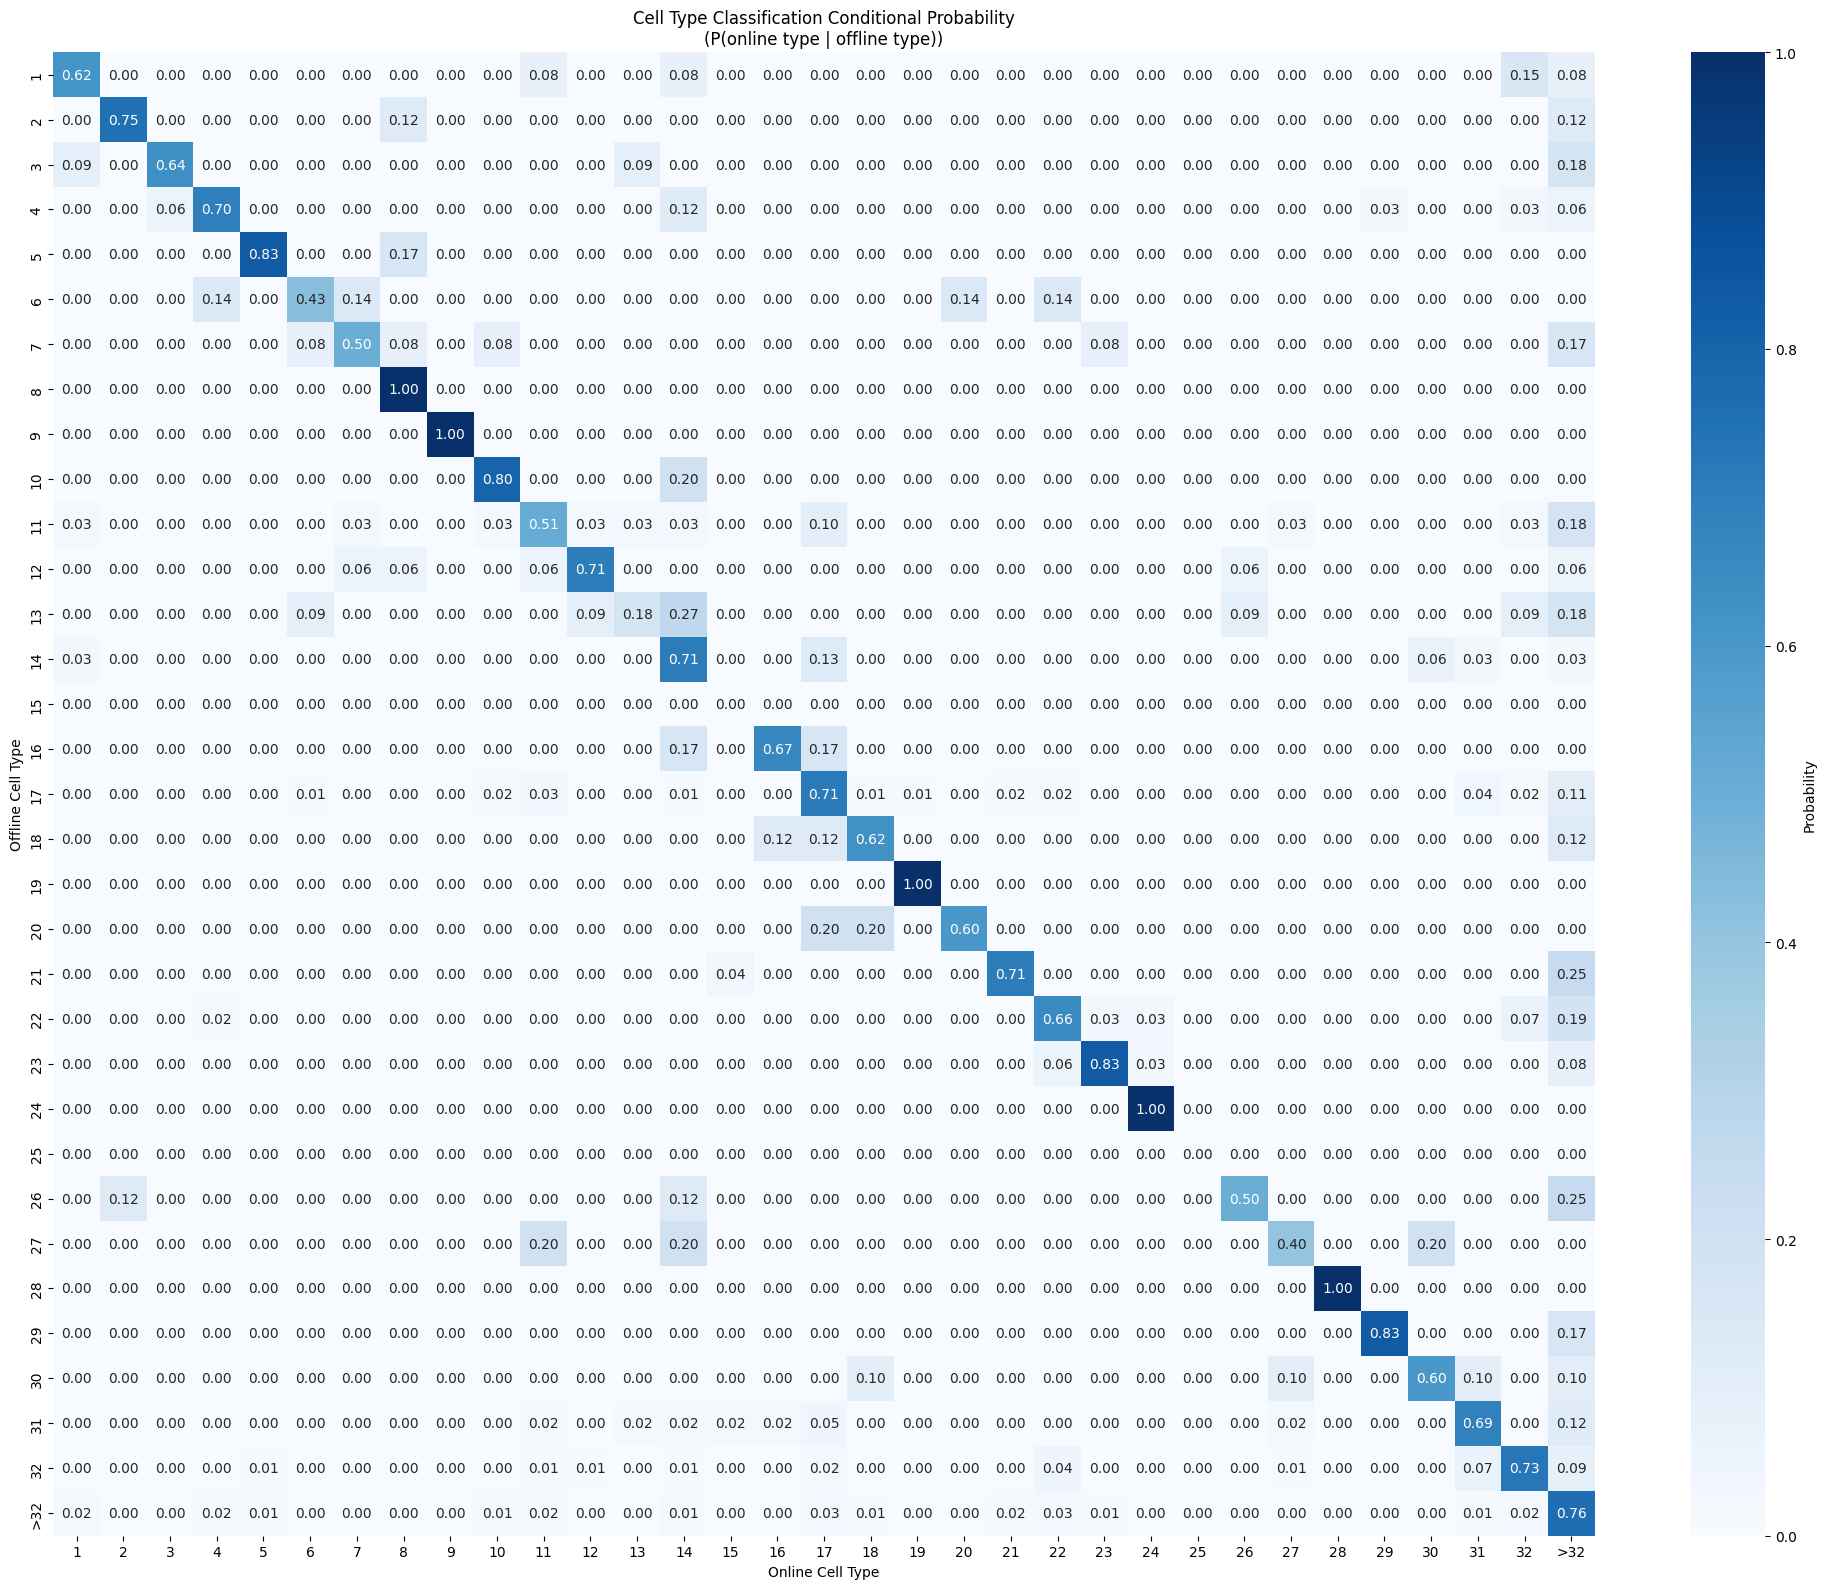

In [155]:
# Example usage:
fig, ax = plot_celltype_confusion_matrix(
    online2offline_celltype_df,
    plot_counts=False,              # Plot counts (False for probabilities)
           # Automatically set mb threshold to exclude bottom 25%
)

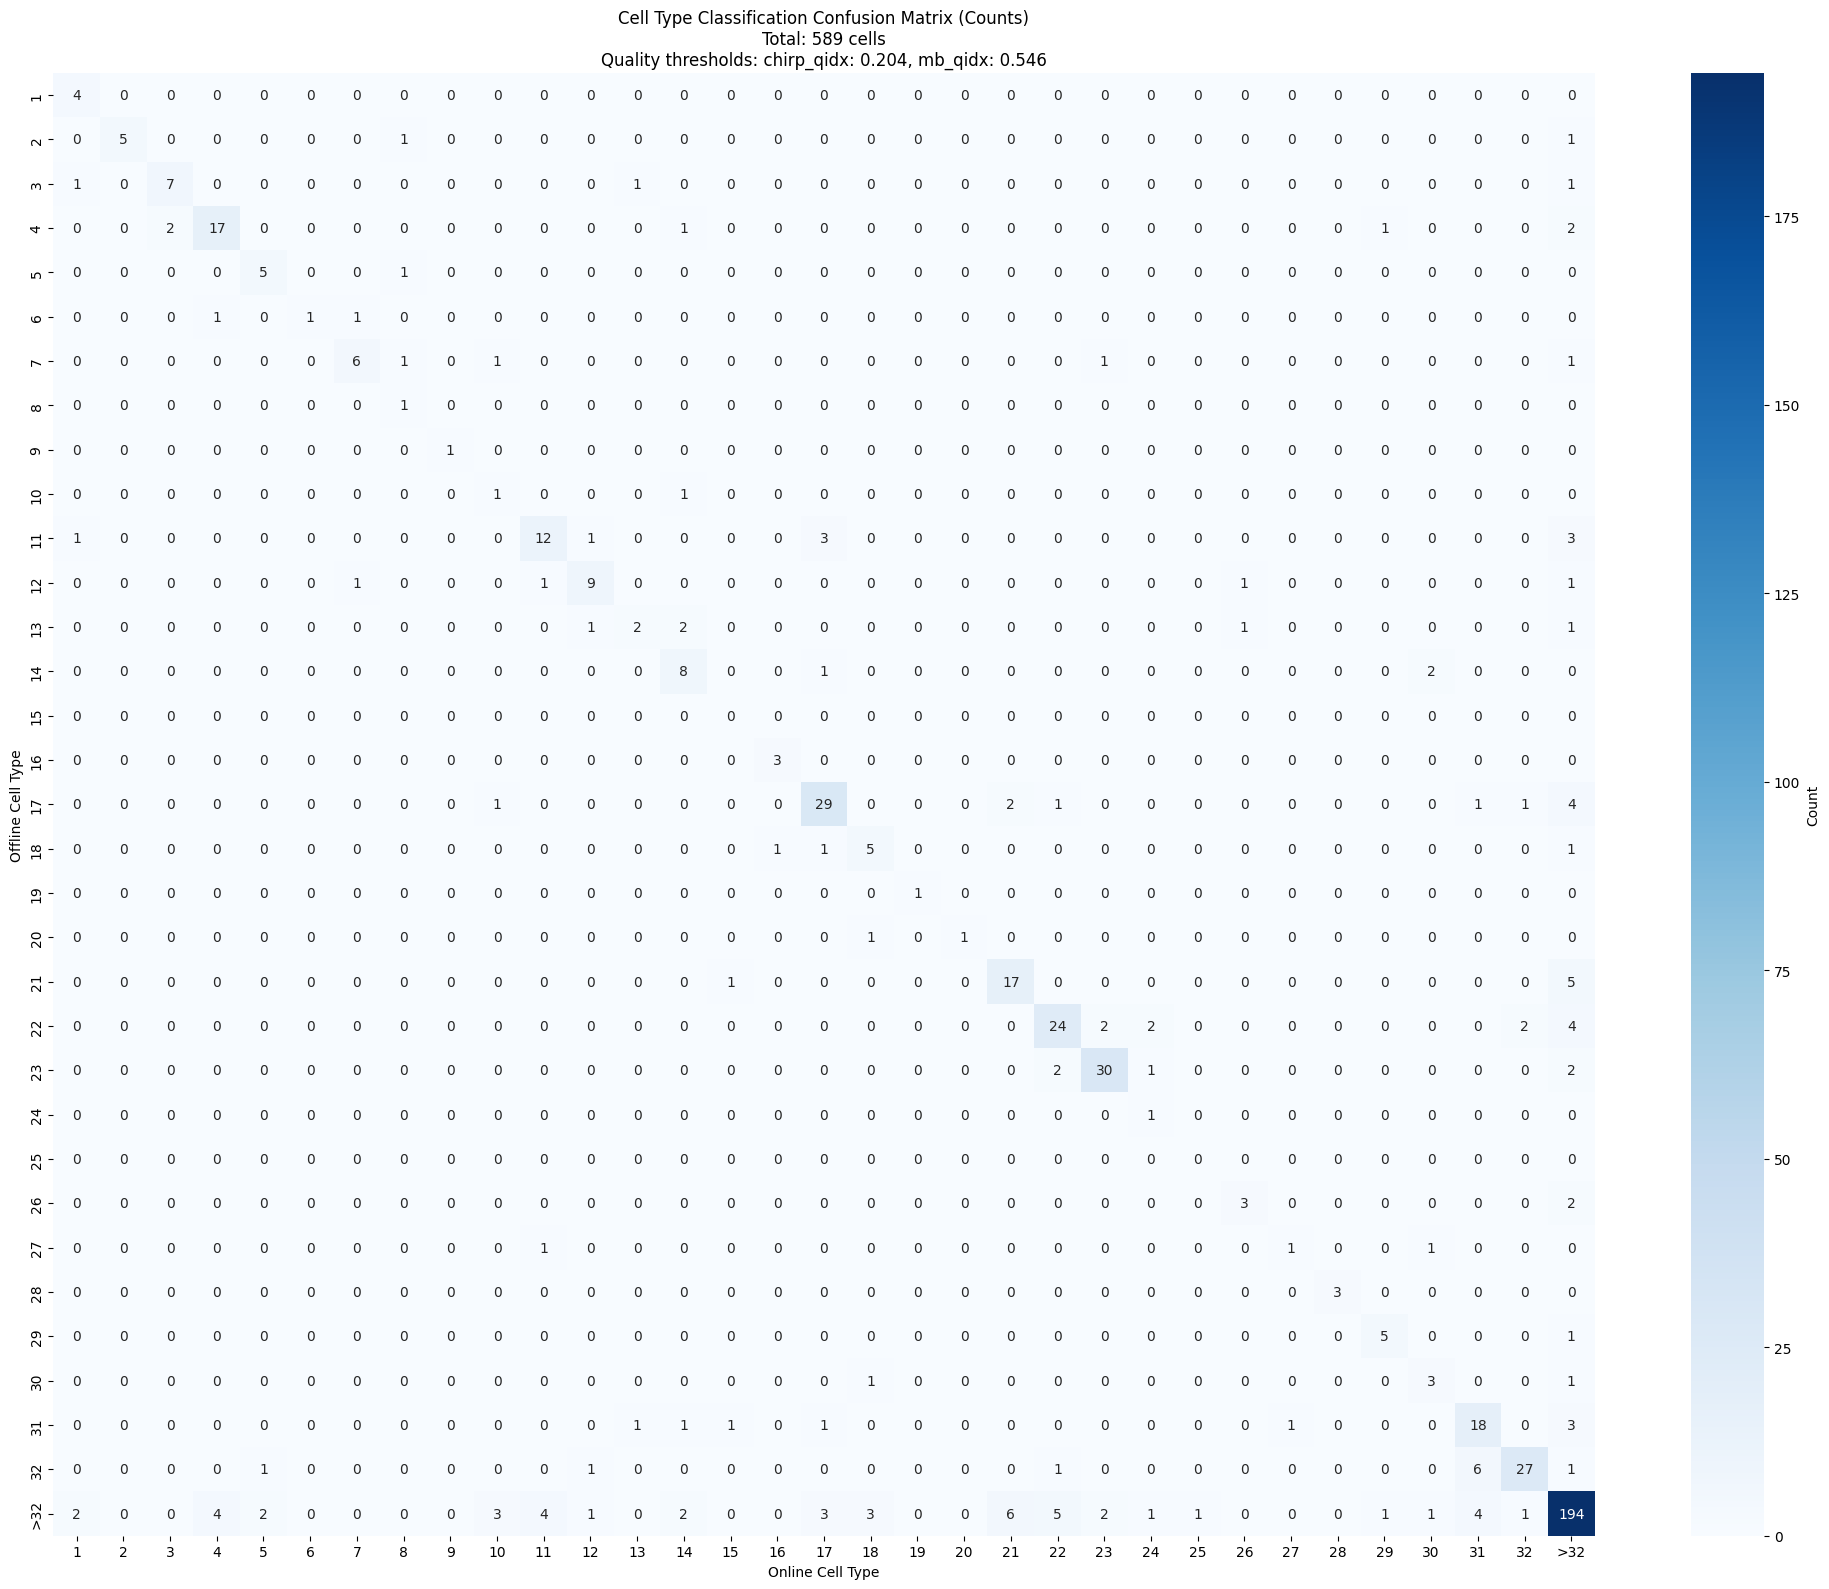

In [ ]:
# Example usage:
fig, ax = plot_celltype_confusion_matrix(
    online2offline_celltype_df,
    plot_counts=True,              # Plot counts (False for probabilities)
    chirp_percentile=25,      # Only include cells with chirp quality index >= 0.3
    mb_percentile=25,              # Automatically set mb threshold to exclude bottom 25%
)

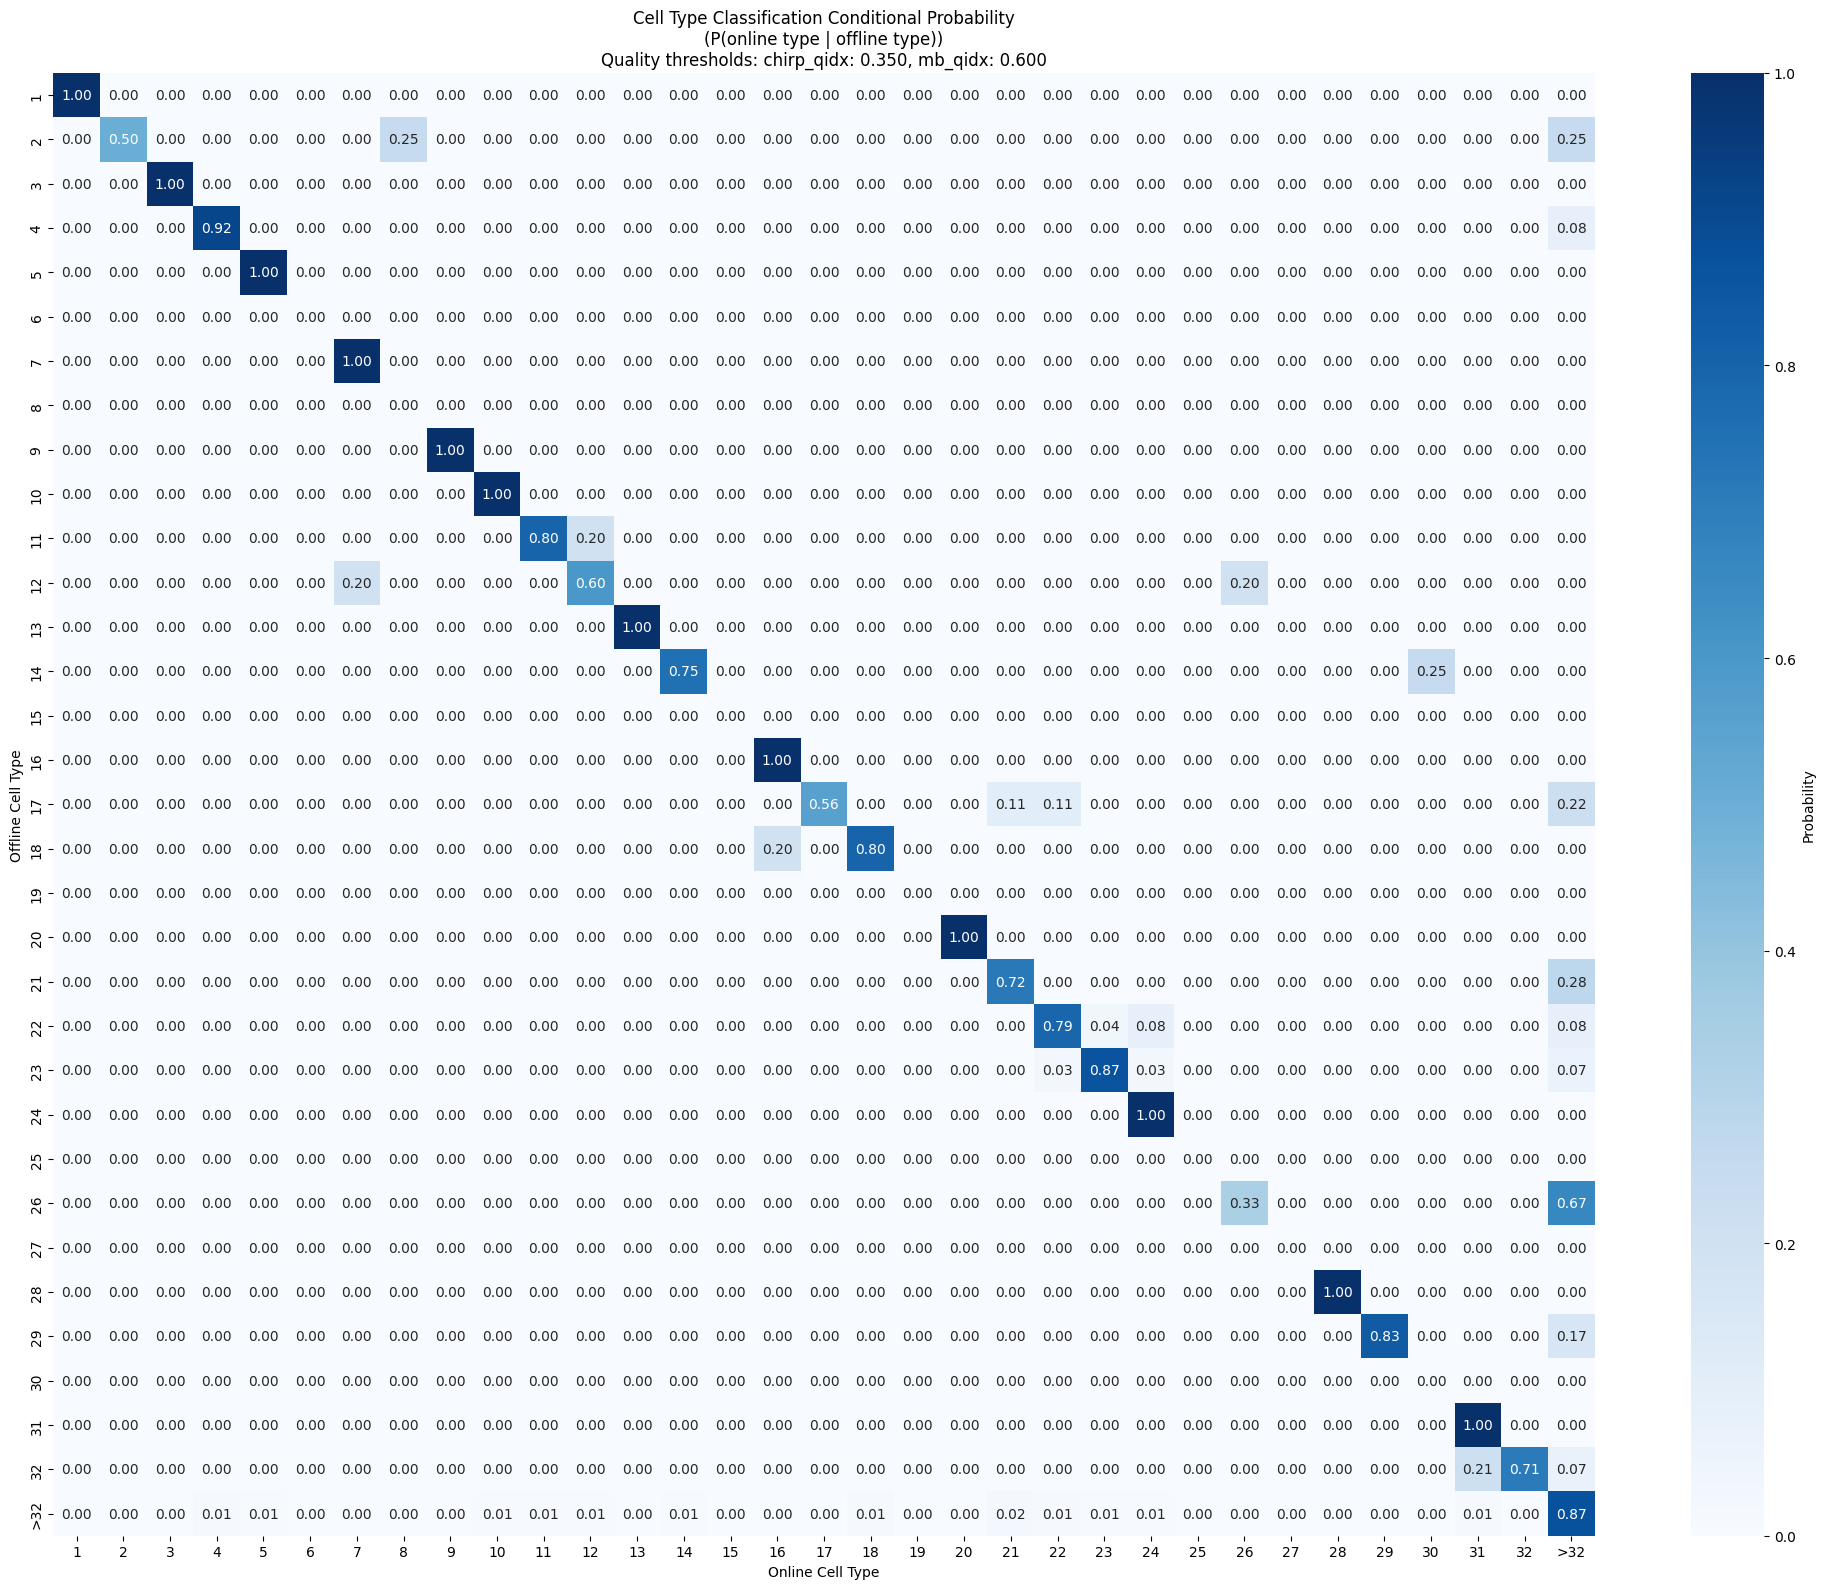

In [ ]:
# Example usage:
fig, ax = plot_celltype_confusion_matrix(
    online2offline_celltype_df,
    plot_counts=False,
    chirp_qidx_threshold=0.35,
    mb_qidx_threshold=0.6,
)

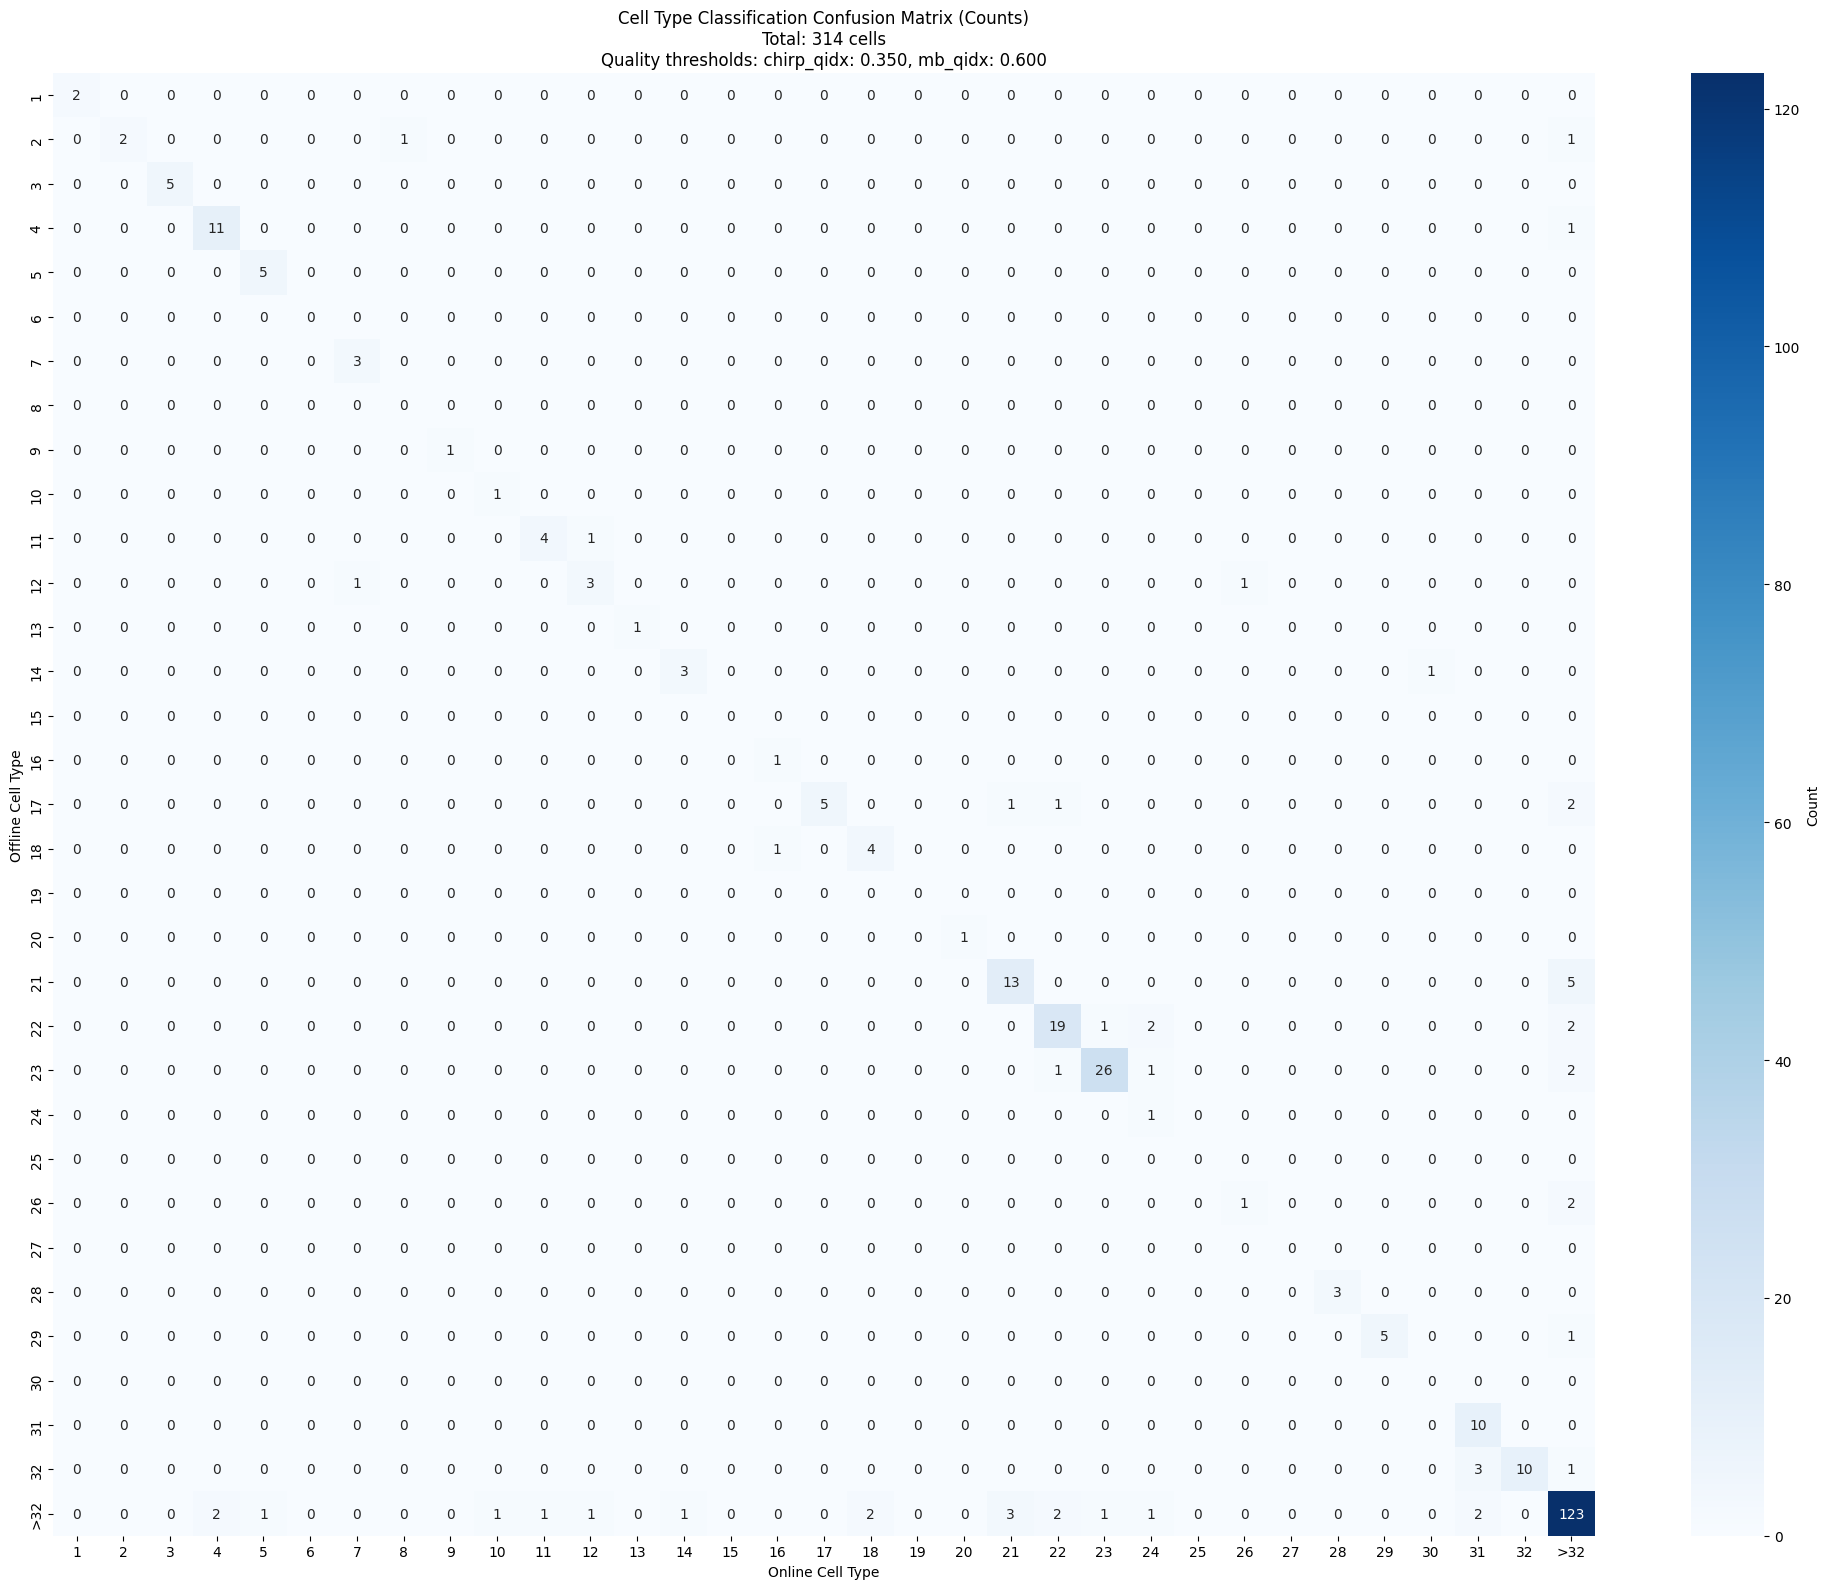

In [150]:
# Example usage:
fig, ax = plot_celltype_confusion_matrix(
    online2offline_celltype_df,
    plot_counts=True,
    chirp_qidx_threshold=0.35,
    mb_qidx_threshold=0.6,
)

In [174]:

from dataclasses import dataclass
from typing import Callable, Dict, Tuple, Optional
import numpy as np
import pandas as pd

@dataclass
class TimingConfig:
    T_total: float
    t_stim: float
    t_pipeline: float
    t_rest: float
    t_switch: float

@dataclass
class ModelConfig:
    target_type: int
    p_types: np.ndarray
    confusion: np.ndarray
    decision_threshold: int = 1
    rng_seed: Optional[int] = None

def draw_field_true_counts_multinomial(N_total: int, p_types: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    return rng.multinomial(N_total, p_types)



def draw_field_true_counts_poisson(lambda_total: float, p_types: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    lambdas = lambda_total * p_types
    return rng.poisson(lambdas)

def draw_online_pred_count_for_target(n_true: np.ndarray, confusion: np.ndarray, target_type: int, rng: np.random.Generator) -> int:
    """
    returnd online pipeline predictions (int) predicted nr of target cells.
    K: nr of cell types
    n_true: (K,) array of true counts of each type in the field
    confusion: (K,K) confusion matrix where confusion[i,j] is the probability of Offline i and online j (row normalized)
    """
    K = n_true.shape[0]
    count = 0
    for i in range(K):
        # probabiiliy of perdicting target_type given true type i
        p_pred_target_given_true = confusion[i, target_type]

        # skip when no true cells of type i or p_hit is 0
        if n_true[i] > 0 and p_pred_target_given_true > 0:

            # draw the number of times  equal to the nr of cells in the field
            count += rng.binomial(n_true[i], p_pred_target_given_true)
    return int(count)

def field_yield_true_target(n_true: np.ndarray, target_type: int) -> int:
    # how many true target cells are in the field
    return int(n_true[target_type])

def run_online(timing: TimingConfig,
               model: ModelConfig,
               draw_field_fn: Callable[..., np.ndarray],
               draw_field_args: Tuple,
               rng: np.random.Generator) -> Dict[str, str |float]:
    t = 0.0
    yield_cells = 0
    fields_visited = 0
    false_positive_fields = 0

    while t + timing.t_stim + timing.t_pipeline + timing.t_switch <= timing.T_total:
        fields_visited += 1

        # generate true cell counts for field
        n_true = draw_field_fn(*draw_field_args, rng=rng)
        
        # get predicted 
        pred_target = draw_online_pred_count_for_target(n_true, model.confusion, model.target_type, rng)
        
        # time spent in chrip/mb and pipeline
        t += (timing.t_stim + timing.t_pipeline)
        
        # still time and predicted desired nr of target cells
        if pred_target >= model.decision_threshold and (t + timing.t_rest) <= timing.T_total:

            # true nr of target cells in field
            true_yield = field_yield_true_target(n_true, model.target_type)
            yield_cells += true_yield
            

            if pred_target > 0 and true_yield == 0:
                false_positive_fields += 1
            
            # time spend with rest of field experiment
            t += timing.t_rest

        #  time the field switching takes
        if t + timing.t_switch > timing.T_total:
            break
        t += timing.t_switch

    return dict(strategy="online",
                yield_cells=yield_cells,
                fields_visited=fields_visited,
                false_positive_fields=false_positive_fields,
                time_used=t)

def run_offline(timing: TimingConfig,
                model: ModelConfig,
                draw_field_fn: Callable[..., np.ndarray],
                draw_field_args: Tuple,
                rng: np.random.Generator) -> Dict[str, float | str]:
    t = 0.0
    yield_cells = 0
    fields_visited = 0

    # Start a field only if you can fully complete stim + rest for it
    while t + timing.t_stim + timing.t_rest <= timing.T_total:
        fields_visited += 1

        n_true = draw_field_fn(*draw_field_args, rng=rng)
        yield_cells += field_yield_true_target(n_true, model.target_type)

        # Pay the full recording cost for this field
        t += (timing.t_stim + timing.t_rest)

        # If there’s time, switch to the next field; otherwise we’re done (final field)
        if t + timing.t_switch <= timing.T_total:
            t += timing.t_switch
        else:
            break

    return dict(strategy="offline",
                yield_cells=yield_cells,
                fields_visited=fields_visited,
                time_used=t)


def simulate(num_trials: int,
             timing: TimingConfig,
             model: ModelConfig,
             generator: str = "multinomial",
             N_total: Optional[int] = None,
             lambda_total: Optional[float] = None) -> pd.DataFrame:
    """
    num_trials: number of trials to simulate
    timing: TimingConfig object with timing parameters
    model: ModelConfig object with model parameters
    generator: "multinomial" or "poisson"
    N_total: total number of cells per field for multinomial generator

    """

    assert generator in ("multinomial", "poisson"), "generator must be 'multinomial' or 'poisson'"
    
    if generator == "multinomial":
        assert isinstance(N_total, int) and N_total >= 0, "Provide N_total >= 0 for multinomial generator"
        draw_field_fn = draw_field_true_counts_multinomial
        draw_field_args = (N_total, model.p_types)
    else:
        assert isinstance(lambda_total, (int, float)) and lambda_total >= 0, "Provide lambda_total >= 0 for poisson generator"
        draw_field_fn = draw_field_true_counts_poisson
        draw_field_args = (float(lambda_total), model.p_types)

    rng = np.random.default_rng(model.rng_seed)
    records = []
    for r in range(num_trials):
        trial_seed = None if model.rng_seed is None else (model.rng_seed + r + 1)
        trial_rng = np.random.default_rng(trial_seed)
        online = run_online(timing, model, draw_field_fn, draw_field_args, trial_rng)
        offline = run_offline(timing, model, draw_field_fn, draw_field_args, trial_rng)
        records.append(online); records.append(offline)
    return pd.DataFrame.from_records(records)

def summarize_results(df: pd.DataFrame) -> (pd.DataFrame, pd.DataFrame):
    by_strategy = df.groupby("strategy").agg(
        mean_yield=("yield_cells", "mean"),
        median_yield=("yield_cells", "median"),
        std_yield=("yield_cells", "std"),
        mean_fields=("fields_visited", "mean"),
        mean_time=("time_used", "mean")
    ).reset_index()
    by_strategy["cells_per_time"] = by_strategy["mean_yield"] / by_strategy["mean_time"].replace(0, np.nan)
    try:
        mean_yield_online = by_strategy.loc[by_strategy["strategy"] == "online", "mean_yield"].values[0]
        mean_yield_off   = by_strategy.loc[by_strategy["strategy"] == "offline", "mean_yield"].values[0]
        mean_time_online = by_strategy.loc[by_strategy["strategy"] == "online", "mean_time"].values[0]
        mean_time_off    = by_strategy.loc[by_strategy["strategy"] == "offline", "mean_time"].values[0]
        delta = pd.DataFrame([{
            "metric": "mean_yield_gain (online - offline)",
            "value": mean_yield_online - mean_yield_off
        }, {
            "metric": "cells_per_time_online",
            "value": mean_yield_online / mean_time_online if mean_time_online > 0 else np.nan
        }, {
            "metric": "cells_per_time_offline",
            "value": mean_yield_off / mean_time_off if mean_time_off > 0 else np.nan
        },{
            "metric":  "percentage_gain",
            "value": 100.0 * (mean_yield_online - mean_yield_off) / mean_yield_off if mean_yield_off > 0 else np.nan
        }])
    except Exception:
        delta = pd.DataFrame([{"metric": "mean_yield_gain (online - offline)", "value": np.nan},
                              {"metric": "cells_per_time_online", "value": np.nan},
                              {"metric": "cells_per_time_offline", "value": np.nan}])
    return by_strategy, delta


In [179]:
df_prepared, applied_thresholds = prepare_celltype_data(
    online2offline_celltype_df, 
    offline_col='offline_cell_type', 
    online_col='online_cell_type', 
    max_type=32,
)

# Step 2: Create the confusion matrices
confusion_counts, confusion_probs = create_confusion_matrices(
    df_prepared, 
    'offline_cell_type' + '_grouped', 
    'online_cell_type' + '_grouped',
    max_type =32
)

# ## with QI 
# df_prepared, applied_thresholds = prepare_celltype_data(
#     online2offline_celltype_df, 
#     offline_col='offline_cell_type', 
#     online_col='online_cell_type', 
#     max_type=32,
#     chirp_qidx_threshold=0.35,
#     mb_qidx_threshold=0.6,
# )

# # Step 2: Create the confusion matrices
# confusion_counts, confusion_probs = create_confusion_matrices(
#     df_prepared, 
#     'offline_cell_type' + '_grouped', 
#     'online_cell_type' + '_grouped',
#     max_type =32
# )

counts = confusion_counts.to_numpy()
prob_type = counts.sum(axis=1) / counts.sum()

C = confusion_probs.to_numpy()

In [ ]:

# Problem setup
K = len(prob_type)
target = 27
p_types = prob_type


timing = TimingConfig(
    T_total=4 * 3600,   #  4 hour
    t_stim= 4 * 60 , # 4 min  
    t_pipeline= 60, # 1 min 
    t_rest=25 * 60, # rest of stimuli (25 min)
    t_switch= 2 * 60# time to select new field (2 min)
)
model = ModelConfig(
    target_type=target,
    p_types=p_types,
    confusion=C,
    decision_threshold=1,
    rng_seed=42
)

# Run simulation (multinomial with fixed cells-per-field)
df = simulate(
    num_trials=1000,
    timing=timing,
    model=model,
    generator="multinomial",
    N_total=100
)

by_strategy, delta = summarize_results(df)
print(by_strategy)
print(delta)

  strategy  mean_yield  median_yield  std_yield  mean_fields  mean_time  \
0  offline       3.818           4.0   1.936653        9.000   14040.00   
1   online       6.913           7.0   1.668597       18.016   14309.04   

   cells_per_time  
0        0.000272  
1        0.000483  
                               metric      value
0  mean_yield_gain (online - offline)   3.095000
1               cells_per_time_online   0.000483
2              cells_per_time_offline   0.000272
3                     percentage_gain  81.063384
